Модели генерации поля:

1. **Гауссовский монохроматический источник** - эталон
2. **Стохастическая модель SERVAL**  - in progress
3. **Набор когерентных Гаусс-Шелл мод**  - in progress
4. **Метод сложения амплитуд** - in progress  

Апертуры:
1. Идеальная (круглая, прямоугольная) - эталон
2. Физические параметры (задание толщины, материала, неровностей) - in progress

```
Генерация источника → пропагация в свободном пространстве z1 → апертура → пропагаця в свободном пространстве z2
```

Вычисляются величины:
- интенсивность I(x,y)
- взаимная функция когерентности J(r₁,r₂)
- глобальная степень когерентности ζ
________
TODO:
- Нормировка интенсивности (единожды для всего кода)
- Корректная J(r₁,r₂)
- Единые модельные параметры

In [3]:
import numpy as np
import scipy.fft as sfft
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy
import time

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
    'figure.figsize': (10, 4),
    'figure.dpi': 100,
})

Для стационарного случайного поля $E(\mathbf{r}, t)$ взаимная функция когерентности:

$$J(\mathbf{r}_1, \mathbf{r}_2) = \langle E^*(\mathbf{r}_1)\, E(\mathbf{r}_2) \rangle$$

угловые скобки - статистическое усреднение по ансамблю реализаций.  

$$J(\mathbf{r}, \mathbf{r}) = \langle |E(\mathbf{r})|^2 \rangle = I(\mathbf{r})$$ - интенсивность.

С нормировкой:

$$\mu(\mathbf{r}_1, \mathbf{r}_2) = \frac{J(\mathbf{r}_1,\mathbf{r}_2)}{\sqrt{I(\mathbf{r}_1)\,I(\mathbf{r}_2)}}$$

Интегральная степень когерентности

$$\zeta = \frac{\iint |J(\mathbf{r}_1,\mathbf{r}_2)|^2\, d\mathbf{r}_1\, d\mathbf{r}_2}{\left(\int I(\mathbf{r})\, d\mathbf{r}\right)^2}$$


Решение уравнения Гельмгольца для монохроматического поля:

$$\frac{\partial^2 E}{\partial z^2} + \nabla_{\perp}^2 E + k^2 E = 0$$

Передаточная функция свободного пространства (угловой спектр):

$$H(k_x, k_y; z) = \exp\!\left[i z \left(\sqrt{k^2 - k_x^2 - k_y^2}\right)\right]$$


In [4]:
class RadiationField:
    """
    Stores a (partially) coherent radiation field in 3-D grid (z, y, x).

    Parameters
    ----------
    shape : (Nz, Ny, Nx) int
    dgrid : (dx, dy, dz) float  [m]  transverse and longitudinal step
    xlamds : float  carrier wavelength [m]
    domain_z : 't' (time/longitudinal coordinate) or 'f' (frequency)
    domain_xy : transverse domain (s - space, k - inverse space)
    """

    def __init__(self, shape=(1, 121, 121), dgrid=(1e-6, 1e-6, 1e-6),
                 xlamds=1e-9, domain_z='t', domain_xy='s'):
        nz, ny, nx = shape
        self.fld = np.zeros((nz, ny, nx), dtype=np.complex128)
        self.fld_stat = []          # list of realization arrays
        self.dx, self.dy, self.dz = dgrid
        self.xlamds = xlamds
        self.domain_z = domain_z
        self.domain_xy = domain_xy

    # ---- basic size properties ----
    def Nx(self): return self.fld.shape[2]
    def Ny(self): return self.fld.shape[1]
    def Nz(self): return self.fld.shape[0]
    def Nstat(self): return len(self.fld_stat)

    def Lx(self): return self.Nx() * self.dx
    def Ly(self): return self.Ny() * self.dy
    def Lz(self): return self.Nz() * self.dz

    # ---- coordinate / frequency axes ----
    def scale_x(self):
        return (np.arange(self.Nx()) - self.Nx() // 2) * self.dx

    def scale_y(self):
        return (np.arange(self.Ny()) - self.Ny() // 2) * self.dy

    def scale_kx(self):
        return sfft.fftshift(sfft.fftfreq(self.Nx(), d=self.dx)) * 2 * np.pi

    def scale_ky(self):
        return sfft.fftshift(sfft.fftfreq(self.Ny(), d=self.dy)) * 2 * np.pi

    # ---- intensity ----
    def intensity(self):
        """Return intensity array (Nz, Ny, Nx) averaged over stat ensemble if available."""
        if len(self.fld_stat) > 0:
            I = np.zeros_like(self.fld, dtype=np.float64)
            for f in self.fld_stat:
                I += np.abs(f) ** 2
            return I / len(self.fld_stat)
        return np.abs(self.fld) ** 2#/np.max(np.abs(self.fld) ** 2)

    def int_xy(self):
        """Intensity in transverse plane averaged over z (or single slice)."""
        return self.intensity().mean(axis=0)

    def int_x(self):
        """1-D marginal intensity along x."""
        return self.int_xy().mean(axis=0)

    def int_y(self):
        """1-D marginal intensity along y."""
        return self.int_xy().mean(axis=1)

    # ---- domain transforms ----
    def fft_xy(self):
        """In-place FFT in transverse plane (toggle s <-> k) """
        for iz in range(self.Nz()):
            self.fld[iz] = sfft.fftshift(
                sfft.fft2(sfft.ifftshift(self.fld[iz])))
            # нормировка?
        if len(self.fld_stat) > 0:
            for idx, f in enumerate(self.fld_stat):
                for iz in range(self.Nz()):
                    f[iz] = sfft.fftshift(sfft.fft2(sfft.ifftshift(f[iz])))
                self.fld_stat[idx] = f
        self.domain_xy = 'k' if self.domain_xy == 's' else 's'

    def fft_z(self):
        """In-place FFT along z (toggle t <-> f)"""
        if self.domain_z == 't':
          self.fld = sfft.fftshift(
              sfft.fft(sfft.ifftshift(self.fld, axes=0), axis=0), axes=0)
          self.domain_z = 'f'
        else:
          self.fld = sfft.fftshift(
              sfft.ifft(sfft.ifftshift(self.fld, axes=0), axis=0), axes=0)
          self.domain_z == 't'

    def ifft_xy(self):
        """In-place IFFT in transverse plane (toggle k <-> s)"""
        for iz in range(self.Nz()):
            self.fld[iz] = sfft.fftshift(
                sfft.ifft2(sfft.ifftshift(self.fld[iz])))
        if len(self.fld_stat) > 0:
            for idx, f in enumerate(self.fld_stat):
                for iz in range(self.Nz()):
                    f[iz] = sfft.fftshift(sfft.ifft2(sfft.ifftshift(f[iz])))
                self.fld_stat[idx] = f
        self.domain_xy = 's' if self.domain_xy == 'k' else 'k'

    def to_domain(self, domains):
        """
        tranfers radiation to specified domains (domain_xy, domain_z)
        *domains is a string with two letters:
            ("t" or "f") and ("s" or "k")
        where
            't' (time); 'f' (frequency); 's' (space); 'k' (inverse space);

        e.g. 'sf', 'st', 'kf', 'kt'

        """
        assert len(domains) == 2
        tgt_xy, tgt_z = domains[0], domains[1]
        if tgt_xy != self.domain_xy:
            self.fft_xy()
        if tgt_z != self.domain_z:
            self.fft_z()

    # ---- free-space propagator ----
    def prop(self, z):

        """
        Propagate field by distance z [m] using angular spectrum method

        can handle wide spectrum
          (every slice in freq.domain is propagated
           according to its frequency)
        no kx**2+ky**2<<k0**2 limitation

        assumes no angular dispersion
        assumes narrow spectrum at center of xlamds

        z>0 -> forward direction
        """
        k0 = 2 * np.pi / self.xlamds
        kx = self.scale_kx()
        ky = self.scale_ky()
        KX, KY = np.meshgrid(kx, ky)
        K2 = KX**2 + KY**2
        # evanescent waves check
        #prop_mask = K2 < k0**2
        #Kz = np.where(prop_mask, np.sqrt(np.maximum(k0**2 - K2, 0.0)), 0.0)
        #H = np.where(prop_mask, np.exp(1j * z * (Kz - k0)), 0.0)
        H = np.exp(1j * z * (np.sqrt(k0 ** 2 - KX ** 2 - KY ** 2)-k0))
        was_s = self.domain_xy == 's'
        if was_s:
            self.fft_xy()

        # apply transfer function
        for iz in range(self.Nz()):
            self.fld[iz] *= H
        if len(self.fld_stat) > 0:
            for f in self.fld_stat:
                for iz in range(self.Nz()):
                    f[iz] *= H

        if was_s:
            self.ifft_xy()

    # ---- coherence functions ----
    def mut_coh_func(self, norm=True):
        """
        Compute mutual coherence function J(x1,x2) along the central y-row.
        Returns 2-D array J[ix1, ix2].
        Uses ensemble average if fld_stat is available, else uses fld directly.
        """
        iy0 = self.Ny() // 2
        if len(self.fld_stat) > 0:
            J = np.zeros((self.Nx(), self.Nx()), dtype=np.complex128)
            for f in self.fld_stat:
                row = f[0, iy0, :]   # shape (Nx,)
                J += np.outer(row.conj(), row)
            J /= len(self.fld_stat)
        else:
            row = self.fld[0, iy0, :]
            J = np.outer(row.conj(), row)

        if norm:
            I_diag = np.abs(np.diag(J))
            denom = np.sqrt(np.outer(I_diag, I_diag)) + 1e-30
            J = J / denom
        return J

    def global_coherence(self):
        """Scalar global degree of coherence zeta = sum|J|^2 / (sum I)^2."""
        iy0 = self.Ny() // 2
        if len(self.fld_stat) > 0:
            J = np.zeros((self.Nx(), self.Nx()), dtype=np.complex128)
            I = np.zeros(self.Nx())
            for f in self.fld_stat:
                row = f[0, iy0, :]
                J += np.outer(row.conj(), row)
                I += np.abs(row)**2
            J /= len(self.fld_stat)
            I /= len(self.fld_stat)
        else:
            row = self.fld[0, iy0, :]
            J = np.outer(row.conj(), row)
            I = np.abs(row)**2

        num = np.sum(np.abs(J)**2)
        denom = np.sum(I)**2 + 1e-30
        return float(num / denom)

    def copy_params(self, other):
        """Copy grid/wavelength parameters from another RadiationField."""
        self.dx = other.dx
        self.dy = other.dy
        self.dz = other.dz
        self.xlamds = other.xlamds
        self.domain_z = other.domain_z
        self.domain_xy = other.domain_xy


def propagate_free_space(dfl, z):
    """
    Propagate RadiationField by distance z [m] using angular spectrum method.

    Handles both single-field (fld) and statistical ensemble (fld_stat).
    Returns a new RadiationField (does not modify in-place).

    Parameters
    ----------
    dfl : RadiationField  (domain_xy must be 's')
    z   : float  propagation distance [m]

    Returns
    -------
    RadiationField  propagated copy
    """
    dfl_out = copy.deepcopy(dfl)
    if dfl_out.domain_xy != 's':
        dfl_out.ifft_xy()
    dfl_out.prop(z)
    return dfl_out


## Функции отрисовки

In [5]:
def _get_field_slice(dfl):
    """Get 2D intensity and phase from dfl (averaged over stat if available)."""
    if len(dfl.fld_stat) > 0:
        I = np.zeros((dfl.Ny(), dfl.Nx()))
        Ph = np.zeros((dfl.Ny(), dfl.Nx()))
        for f in dfl.fld_stat:
            I  += np.abs(f[0])**2
            Ph += np.angle(f[0])
        I  /= len(dfl.fld_stat)
        Ph /= len(dfl.fld_stat)
    else:
        I  = np.abs(dfl.fld[0])**2
        Ph = np.angle(dfl.fld[0])
    return I/np.max(I), Ph


def plot_field(dfl, title=''):
    """
    2-panel plot: intensity |E|^2 and phase of E in transverse plane.
    """
    I, Ph = _get_field_slice(dfl)
    x = dfl.scale_x() * 1e6  # um
    y = dfl.scale_y() * 1e6

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    extent = [x[0], x[-1], y[0], y[-1]]

    im0 = axes[0].imshow(I, origin='lower', extent=extent,
                          cmap='inferno', aspect='equal')
    axes[0].set_xlabel('$x$, um')
    axes[0].set_ylabel('$y$, um')
    plt.colorbar(im0, ax=axes[0], label='Intensity, a.u.')

    im1 = axes[1].imshow(Ph, origin='lower', extent=extent,
                          cmap='twilight', aspect='equal',
                          vmin=-np.pi, vmax=np.pi)

    axes[1].set_xlabel('$x$, um')
    axes[1].set_ylabel('$y$, um')
    cbar = plt.colorbar(im1, ax=axes[1], label='Phase, rad')
    cbar.set_ticks([-np.pi, 0, np.pi])
    cbar.set_ticklabels([r'$-\pi$', r'$0$', r'$\pi$'])

    plt.tight_layout()
    plt.show()


def plot_mcf_2d(dfl, title=''):
    """
    2D map of |J(x1, x2)| — mutual coherence function (un-normalised).
    """
    iy0 = dfl.Ny() // 2
    if len(dfl.fld_stat) > 0:
        J = np.zeros((dfl.Nx(), dfl.Nx()), dtype=np.complex128)
        for f in dfl.fld_stat:
            row = f[0, iy0, :]
            J += np.outer(row.conj(), row)
        J /= len(dfl.fld_stat)
    else:
        row = dfl.fld[0, iy0, :]
        J = np.outer(row.conj(), row)

    x = dfl.scale_x() * 1e6
    extent = [x[0], x[-1], x[0], x[-1]]

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(np.abs(J), origin='lower', extent=extent,
                   cmap='hot', aspect='equal')
    ax.set_xlabel("$x_1$, um")
    ax.set_ylabel("$x_2$, um")
    plt.colorbar(im, ax=ax, label='$|J(x_1,x_2)|$')
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()


## Генерация излучения

### Параметры источника

| Параметр | Обозначение | Значение (уточнить!) |
|---|---|---|
| Горизонтальный размер пучка | $\sigma_x$ | 34 мкм |
| Вертикальный размер пучка | $\sigma_y$ | 12 мкм |
| Горизонтальная угловая расходимость | $\sigma_{x'}$ | 17 мкм рад |
| Вертикальная угловая расходимость | $\sigma_{y'}$ | 17 мкм рад |
| Горизонтальный эмиттанс | $\varepsilon_x = \sigma_x \sigma_{x'}$ | ~0.6 нм·рад |
| Вертикальный эмиттанс | $\varepsilon_y = \sigma_y \sigma_{y'}$ | ? |


### 1. Гауссовский монохроматический источник

Идеальный полностью когерентный гауссовский пучок. Поперечное поле в перетяжке:

$$E(x,y) = A \exp\!\left(-\frac{x^2+y^2}{4\,w^2}\right)$$


In [6]:
def generate_gaussian_source(xlamds, shape, dgrid, sigma_xy, sigma_z=None,
                              power_waistpos=0.0, power=1.0):
    """
    Generate a monochromatic Gaussian beam.

    Parameters
    ----------
    xlamds : float  wavelength [m]
    shape  : (Nz, Ny, Nx) grid shape
    dgrid  : (dx, dy, dz) grid steps [m]
    sigma_xy : float  transverse RMS field size [m]  (sigma, not FWHM)
    sigma_z  : float  longitudinal envelope RMS [m]  (None -> flat pulse)
    power_waistpos : float  z-position of waist relative to grid center [m]
    power  : float  total power [W] (field scaled accordingly)

    Returns
    -------
    RadiationField
    """
    dfl = RadiationField(shape=shape, dgrid=dgrid, xlamds=xlamds,
                         domain_z='t', domain_xy='s')
    nz, ny, nx = shape
    dx, dy, dz = dgrid

    x = (np.arange(nx) - nx // 2) * dx
    y = (np.arange(ny) - ny // 2) * dy
    z = (np.arange(nz) - nz // 2) * dz

    X, Y = np.meshgrid(x, y)
    # transverse Gaussian (field amplitude, NOT intensity)
    E_xy = np.exp(-(X**2 + Y**2) / (4 * sigma_xy**2)).astype(np.complex128)

    for iz in range(nz):
        if sigma_z is not None:
            z_env = np.exp(-z[iz]**2 / (4 * sigma_z**2))
        else:
            z_env = 1.0
        dfl.fld[iz] = E_xy * z_env

    # normalise to desired power
    I_total = np.sum(np.abs(dfl.fld[0])**2) * dx * dy
    if I_total > 0:
        dfl.fld *= np.sqrt(power / I_total)

    return dfl


### Модель SERVAL

SERVAL генерирует реализации частично когерентного поля на основе стохастического подхода.

**Алгоритм:**
1. Генерация комплексного гауссовского белого шума $\xi(x,y)$
2. Умножение на огибающую пучка: $E'(x,y) = \xi(x,y) \cdot A(x,y)$,  
   где $A(x,y) = \exp(-(x^2/4\sigma_x^2 + y^2/4\sigma_y^2))$
3. Переход в $k$-пространство: $\tilde{E}'(k_x,k_y) = \mathcal{F}[E']$
4. Умножение на угловое распределение поворотного магнита (Гаусс с $\sigma_{\rm ang} \approx 1/\gamma$):
   $\tilde{E}''(k_x,k_y) = \tilde{E}' \cdot B(k_x,k_y)$
5. Обратное преобразование Фурье: $E_{\rm out} = \mathcal{F}^{-1}[\tilde{E}'']$


- Vartanyants I.A. & Singer A. *New J. Phys.* **12**, 035004 (2010)  
- Geloni G. et al. *Optics Comm.* **276**, 167 (2007)


In [7]:
def generate_serval(xlamds, shape, dgrid, sig_x, sig_y, sig_xp, sig_yp,
                    N_realizations=50, seed=42):
    """
    SERVAL stochastic algorithm for partially coherent field.

    Parameters
    ----------
    xlamds        : float  wavelength [m]
    shape         : (Nz, Ny, Nx)
    dgrid         : (dx, dy, dz)
    sig_x, sig_y  : float  source RMS size [m]
    sig_xp, sig_yp: float  source RMS divergence [rad]
    N_realizations: int    number of statistically independent realizations
    seed          : int    random seed

    Returns
    -------
    RadiationField with fld_stat populated
    """
    nz, ny, nx = shape
    dx, dy, dz = dgrid
    k0 = 2 * np.pi / xlamds

    x = (np.arange(nx) - nx // 2) * dx
    y = (np.arange(ny) - ny // 2) * dy
    X, Y = np.meshgrid(x, y)

    kx = sfft.fftshift(sfft.fftfreq(nx, d=dx)) * 2 * np.pi
    ky = sfft.fftshift(sfft.fftfreq(ny, d=dy)) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky)

    # Spatial envelope (source beam size)
    A_xy = np.exp(-(X**2 / (4 * sig_x**2) + Y**2 / (4 * sig_y**2)))

    # Angular filter: BM angular distribution
    # theta_x ~ k_x/k0, theta_y ~ k_y/k0
    # sigma_angle_x = sig_xp (divergence), sigma_angle_y = sig_yp
    # Coherence envelope in k-space ∝ exp(-kx^2 * sig_x^2 - ky^2 * sig_y^2)
    # (Fourier transform of spatial coherence)
    sigma_kx = 1.0 / (2 * sig_x) if sig_x > 0 else 1e6   # coherence in k
    sigma_ky = 1.0 / (2 * sig_y) if sig_y > 0 else 1e6

    # Radiation angular spectrum for BM (Gaussian approximation)
    ang_sigma_kx = k0 * sig_xp  # [1/m] in k-space
    ang_sigma_ky = k0 * sig_yp

    # Combined k-space filter
    B_kxy = np.exp(-(KX**2 / (2 * ang_sigma_kx**2) +
                     KY**2 / (2 * ang_sigma_ky**2)))

    rng = np.random.default_rng(seed)
    dfl = RadiationField(shape=shape, dgrid=dgrid, xlamds=xlamds,
                         domain_z='t', domain_xy='s')

    for _ in range(N_realizations):
        field = np.zeros((nz, ny, nx), dtype=np.complex128)
        for iz in range(nz):
            # 1. White noise
            noise = (rng.standard_normal((ny, nx)) +
                     1j * rng.standard_normal((ny, nx))) / np.sqrt(2)
            # 2. Spatial shaping
            E_space = noise * A_xy
            # 3. k-space angular filter
            E_k = sfft.fftshift(sfft.fft2(sfft.ifftshift(E_space)))
            E_k *= B_kxy
            # 4. Back to real space
            E_out = sfft.fftshift(sfft.ifft2(sfft.ifftshift(E_k)))
            field[iz] = E_out
        dfl.fld_stat.append(field)

    # Set mean field
    dfl.fld = np.mean(np.array(dfl.fld_stat), axis=0)

    # Normalise so mean intensity = 1 W/m^2
    I_avg = np.mean([np.sum(np.abs(f)**2) * dx * dy for f in dfl.fld_stat])
    if I_avg > 0:
        scale = 1.0 / np.sqrt(I_avg)
        dfl.fld_stat = [f * scale for f in dfl.fld_stat]
        dfl.fld *= scale

    return dfl

'''
# smoke test
_dfl_serval = generate_serval(
    xlamds=1.2e-9, shape=(1, 51, 51),
    dgrid=(5e-6, 5e-6, 1e-6),
    sig_x=34.4e-6, sig_y=11.7e-6,
    sig_xp=17.5e-6, sig_yp=17.4e-6,
    N_realizations=10, seed=0)
print(f"SERVAL source: shape={_dfl_serval.fld.shape}, "
      f"Nstat={_dfl_serval.Nstat()}, "
      f"zeta={_dfl_serval.global_coherence():.4f}")
'''

'\n# smoke test\n_dfl_serval = generate_serval(\n    xlamds=1.2e-9, shape=(1, 51, 51),\n    dgrid=(5e-6, 5e-6, 1e-6),\n    sig_x=34.4e-6, sig_y=11.7e-6,\n    sig_xp=17.5e-6, sig_yp=17.4e-6,\n    N_realizations=10, seed=0)\nprint(f"SERVAL source: shape={_dfl_serval.fld.shape}, "\n      f"Nstat={_dfl_serval.Nstat()}, "\n      f"zeta={_dfl_serval.global_coherence():.4f}")\n'

### Идеальная апертура

$T(x,y) = \begin{cases} 1, & (x,y) \in \Omega \\ 0, & \text{иначе} \end{cases}$


In [8]:
class IdealAperture:
    """
    Hard-edge aperture (transmission = 1 inside, 0 outside).

    Parameters
    ----------
    shape : 'rect' | 'circ'
    size  : float or (float, float)
        For 'rect': (width_x, height_y) or single value for square
        For 'circ': radius R
    """

    def __init__(self, shape='rect', size=100e-6):
        self.shape = shape
        if isinstance(size, (int, float)):
            self.size = (float(size), float(size))
        else:
            self.size = tuple(size)

    def mask(self, dfl):
        """Return 2D transmission mask (Ny, Nx) for given RadiationField."""
        nx, ny = dfl.Nx(), dfl.Ny()
        x = dfl.scale_x()
        y = dfl.scale_y()
        X, Y = np.meshgrid(x, y)
        if self.shape == 'rect':
            ax, ay = self.size[0] / 2, self.size[1] / 2
            T = ((np.abs(X) <= ax) & (np.abs(Y) <= ay)).astype(np.float64)
        elif self.shape == 'circ':
            R = self.size[0]
            T = (np.sqrt(X**2 + Y**2) <= R).astype(np.float64)
        else:
            raise ValueError(f"Unknown aperture shape: {self.shape}")
        return T

    def apply(self, dfl):
        """Apply aperture mask to RadiationField (in-place)."""
        T = self.mask(dfl)
        assert dfl.domain_xy == 's', "Aperture must be applied in spatial domain"
        for iz in range(dfl.Nz()):
            dfl.fld[iz] *= T
        if len(dfl.fld_stat) > 0:
            for f in dfl.fld_stat:
                for iz in range(dfl.Nz()):
                    f[iz] *= T



## Моделирование оптического тракта


In [12]:
# Параметры электронного пучка
E_beam_GeV   = 3.0          # энергия электронного пучка [ГэВ]
I_beam_A     = 0.4          # ток пучка [А]

# Энергия и длина волны
E_photon_eV  = 530.0        # энергия фотонов [эВ]
hc_eVm       = 1239.84e-9   # h*c [эВ·м]
xlamds       = hc_eVm / E_photon_eV   # длина волны [м]
m_e_GeV = 0.511e-3
gamma_rel = E_beam_GeV / m_e_GeV

# Поперечные размеры и угловые расходимости источника
sig_x        = 0.03261e-3      # горизонтальный RMS размер [м]
sig_y        = 4.020e-6      # вертикальный RMS размер [м]
sig_xp       = 2.091e-6     # горизонтальная угловая расходимость [рад]
sig_yp       = 1.696e-6      # вертикальная угловая расходимость [рад]

# Геометрия оптического тракта
z1           = 10.0         # расстояние источник-апертура [м]
z2           = 1.0          # расстояние апертура-детектор [м]
ap_size      = 250e-6       # размер апертуры [м]

# Сетка
Nx_grid = Ny_grid = 501     # число точек сетки
Lx_grid = Ly_grid = 2e-3   # размер поля в поперечном сечении [м]
dx_grid = Lx_grid / Nx_grid
dy_grid = Ly_grid / Ny_grid
dz_grid = 50e-6              # продольный шаг (одна плоскость Nz=1)

SHAPE = (101, Ny_grid, Nx_grid)
DGRID = (dx_grid, dy_grid, dz_grid)

N_realiz = 1          # число реализаций (SERVAL)

print(f"Длина волны: {xlamds*1e9:.3f} нм")
print(f"Лорентц-фактор γ = {gamma_rel:.0f}")
print(f"Сетка: {Nx_grid}×{Ny_grid}, шаг {dx_grid*1e6:.3f} мкм, "
      f"поле {Lx_grid*1e3:.3f} мм")


Длина волны: 2.339 нм
Лорентц-фактор γ = 5871
Сетка: 501×501, шаг 3.992 мкм, поле 2.000 мм


## Гауссовский монохроматический источник

Время: 10.79 с
Интегральная когерентность ζ = 1.00


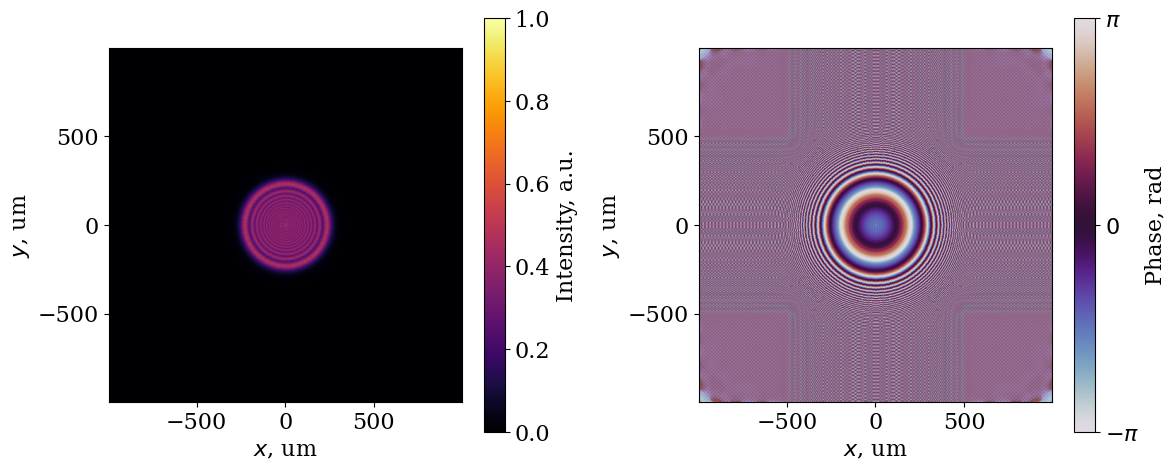

In [10]:
t0 = time.time()

dfl_gauss = generate_gaussian_source(
    xlamds=xlamds, shape=SHAPE, dgrid=DGRID,
    sigma_xy=sig_y, power=1.0)

dfl_gauss_ap = propagate_free_space(dfl_gauss, z=z1)

aperture_ideal = IdealAperture(shape='circ', size=ap_size)
aperture_ideal.apply(dfl_gauss_ap)

dfl_gauss_det = propagate_free_space(dfl_gauss_ap, z=z2)

print(f"Время: {time.time()-t0:.2f} с")
print(f"Интегральная когерентность ζ = {dfl_gauss_det.global_coherence():.2f}")

plot_field(dfl_gauss_det)

### SERVAL

Время: 29.21 с
Интегральная когерентность ζ = 1.00


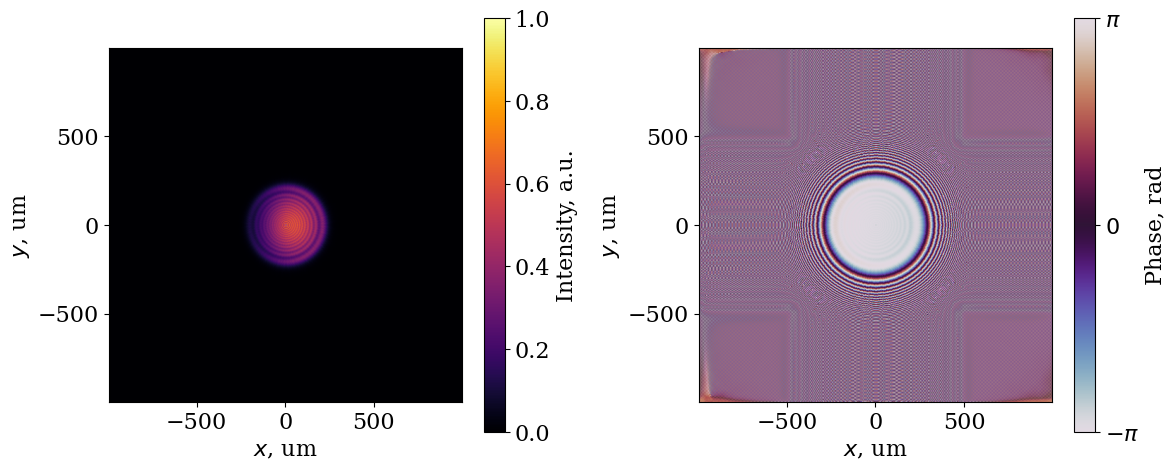

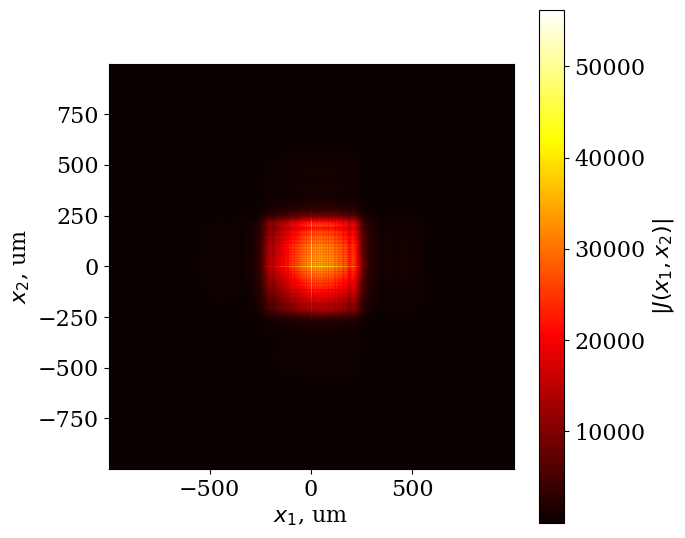

In [13]:
t0 = time.time()

dfl_serval = generate_serval(
    xlamds=xlamds, shape=SHAPE, dgrid=DGRID,
    sig_x=sig_x, sig_y=sig_y,
    sig_xp=sig_xp, sig_yp=sig_yp,
    N_realizations=N_realiz, seed=12345)

dfl_serval_ap = propagate_free_space(dfl_serval, z=z1)

aperture_ideal.apply(dfl_serval_ap)

dfl_serval_det = propagate_free_space(dfl_serval_ap, z=z2)

print(f"Время: {time.time()-t0:.2f} с")
print(f"Интегральная когерентность ζ = {dfl_serval_det.global_coherence():.2f}")

plot_field(dfl_serval_det)
plot_mcf_2d(dfl_serval_det)
